# Reloading

Sometimes vehicles can execute multiple trips during their shift, by reloading at the depot when needed.
This effectively mitigates the capacity constraint we have so far seen, because vehicles can always choose to return to the depot to reload if needed.
PyVRP supports a very general form of reloading, with free depot selection from a list of alternatives.
Optionally, the maximum number of reloads per vehicle type may also be restricted.

In [1]:
import pyvrp
import pyvrp.plotting
import pyvrp.stop

We will investigate a simple example, with a single vehicle having a capacity of 15.
Without reloading, the clients demand more than the vehicle can carry.
By reloading at the depot, the vehicle can service all client demand in two trips. 

In [2]:
COORDS = [(456, 320), (312, 418), (114, 80), (570, 160), (684, 240)]
DEMANDS = [5, 8, 7, 6]

In [3]:
m = pyvrp.Model()


depot = m.add_depot(location=m.add_location(COORDS[0][0], COORDS[0][1]))
m.add_vehicle_type(
    1,
    capacity=15,
    reload_depots=[depot],  # where reloads may take place
    max_reloads=2,  # maximum number of reload depot visits on a route
)

for idx in range(1, len(COORDS)):
    m.add_client(
        location=m.add_location(x=COORDS[idx][0], y=COORDS[idx][1]),
        delivery=DEMANDS[idx - 1],
    )

for frm in m.locations:
    for to in m.locations:
        distance = abs(frm.x - to.x) + abs(frm.y - to.y)
        m.add_edge(frm, to, distance=distance)

res = m.solve(stop=pyvrp.stop.MaxRuntime(1))

PyVRP v0.14.0


Solving an instance with:


    1 depot


    4 clients


    0 shipments


...

   objective: 2136


    distance: 2136


    duration: 0


# iterations: 46564


    run-time: 1.00 seconds


Returns to a reload depot are marked with a `|`, as follows:

In [4]:
print(res.best)

Route #1: C3 C2 | C0 C1



Let's investigate the route in more detail:

In [5]:
route = res.best.routes()[0]

print("Route plan:")
for activity in route:
    print(f" - At {activity}, on trip {activity.trip}.")

Route plan:
 - At D0, on trip 0.
 - At C3, on trip 0.
 - At C2, on trip 0.
 - At D0, on trip 1.
 - At C0, on trip 1.
 - At C1, on trip 1.
 - At D0, on trip 2.


The trip counter starts at zero, and is incremented at every subsequent (reload) depot visit.

A plot reveals the routing and reloading decisions that PyVRP determined:

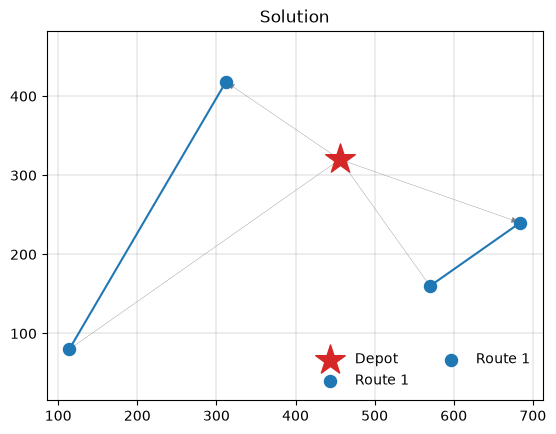

In [6]:
pyvrp.plotting.plot_solution(res.best, m.data(), plot_locations=True)

## Conclusion

You now know how to use PyVRP's reloading feature.
PyVRP's support for reloading is very general, and is useful in many settings, like urban last-mile (return to the warehouse to pick up new goods), waste collection (to empty a full truck at a landfill or recycling centre), and more.